In [5]:
# Notebook 03: Exploratory Analysis
# Author: Eric Lindolfo, B.Eng
# Goal: Answer Q1, Q2, Q3, Q4 using cleaned datasets

import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

# Load cleaned datasets
inventory = pd.read_csv('data/processed/inventory_clean.csv',
                        parse_dates=['Date_Received', 'Last_Order_Date', 
                                     'Expiration_Date', 'Expiration_Date_Adjusted'])

sales = pd.read_csv('data/processed/sales_clean.csv',
                    parse_dates=['transaction_date'])

print("Datasets loaded successfully!")
print("Inventory shape:", inventory.shape)
print("Sales shape:", sales.shape)

Datasets loaded successfully!
Inventory shape: (990, 21)
Sales shape: (1980, 11)


In [6]:
# ============================================================
# Q1 — EXPIRED INVENTORY RISK
# Goal: Identify SKUs with highest expiry risk
# Business context: Products expiring before being sold
# = write-off cost + working capital loss
# ============================================================

# Risk distribution summary
risk_summary = inventory['expiry_risk_flag'].value_counts().reset_index()
risk_summary.columns = ['Risk Level', 'Count']
risk_summary['Percentage'] = (risk_summary['Count'] / len(inventory) * 100).round(1)

print("=== INVENTORY RISK DISTRIBUTION ===")
print(risk_summary)

at_risk = inventory[inventory['expiry_risk_flag'].isin(['HIGH', 'EXPIRED'])].shape[0]
at_risk_pct = round(at_risk / len(inventory) * 100, 1)

print(f"\nTotal products at risk (HIGH + EXPIRED): {at_risk}")
print(f"Percentage of total inventory: {at_risk_pct}%")

=== INVENTORY RISK DISTRIBUTION ===
  Risk Level  Count  Percentage
0        LOW    624        63.0
1    EXPIRED    183        18.5
2       HIGH    116        11.7
3     MEDIUM     67         6.8

Total products at risk (HIGH + EXPIRED): 299
Percentage of total inventory: 30.2%


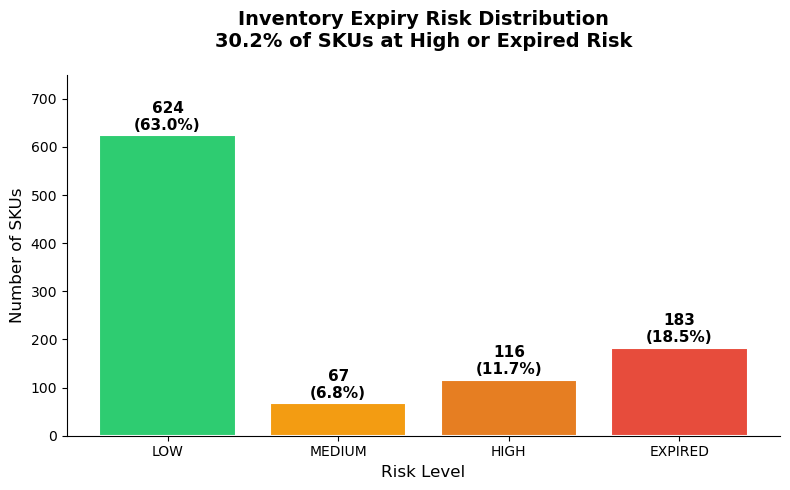

Chart saved!


In [7]:
# Q1 — Visualization: Inventory Risk Distribution
# Goal: Create a clear visual for the Power BI dashboard and README

fig, ax = plt.subplots(figsize=(8, 5))

colors = {'LOW': '#2ecc71', 'MEDIUM': '#f39c12', 'HIGH': '#e67e22', 'EXPIRED': '#e74c3c'}
risk_order = ['LOW', 'MEDIUM', 'HIGH', 'EXPIRED']

risk_plot = risk_summary.set_index('Risk Level').reindex(risk_order)

bars = ax.bar(risk_plot.index, 
              risk_plot['Count'],
              color=[colors[r] for r in risk_order],
              edgecolor='white',
              linewidth=1.5)

# Add value labels on bars
for bar, pct in zip(bars, risk_plot['Percentage']):
    ax.text(bar.get_x() + bar.get_width()/2, 
            bar.get_height() + 5,
            f'{int(bar.get_height())}\n({pct}%)',
            ha='center', va='bottom', fontsize=11, fontweight='bold')

ax.set_title('Inventory Expiry Risk Distribution\n30.2% of SKUs at High or Expired Risk', 
             fontsize=14, fontweight='bold', pad=20)
ax.set_xlabel('Risk Level', fontsize=12)
ax.set_ylabel('Number of SKUs', fontsize=12)
ax.set_ylim(0, 750)
ax.spines['top'].set_visible(False)
ax.spines['right'].set_visible(False)

plt.tight_layout()

# Save chart
import os
os.makedirs('outputs/charts', exist_ok=True)
plt.savefig('outputs/charts/Q1_inventory_risk_distribution.png', dpi=150, bbox_inches='tight')
plt.show()

print("Chart saved!")

In [8]:
# Q1 — Top 20 SKUs at highest risk
# Focus on EXPIRED and HIGH risk products
# Sorted by days_to_expiry (most urgent first)

at_risk_products = inventory[inventory['expiry_risk_flag'].isin(['EXPIRED', 'HIGH'])].copy()
at_risk_products = at_risk_products.sort_values('days_to_expiry').head(20)

print("=== TOP 20 PRODUCTS AT HIGHEST EXPIRY RISK ===")
print(at_risk_products[['Product_Name', 'Category', 'expiry_risk_flag', 
                          'days_to_expiry', 'days_of_supply', 
                          'Stock_Quantity', 'Sales_Volume']].to_string(index=False))

=== TOP 20 PRODUCTS AT HIGHEST EXPIRY RISK ===
     Product_Name            Category expiry_risk_flag  days_to_expiry  days_of_supply  Stock_Quantity  Sales_Volume
Chocolate Biscuit              Bakery          EXPIRED             -65             3.8              11            88
   Robusta Coffee           Beverages          EXPIRED             -65            19.7              59            90
   Cheddar Cheese               Dairy          EXPIRED             -65             9.1              21            69
      Bread Flour     Grains & Pulses          EXPIRED             -65            27.4              84            92
           Salmon             Seafood          EXPIRED             -65            27.5              88            96
      Pomegranate Fruits & Vegetables          EXPIRED             -63             4.9              14            86
  Evaporated Milk               Dairy          EXPIRED             -63            25.9              64            74
        Wild Rice

In [9]:
# ============================================================
# Q2 — FEFO COMPLIANCE RISK
# Goal: Which categories have lowest turnover with shortest shelf life?
# Business context: Low turnover + short shelf life = FEFO violation risk
# ============================================================

# Calculate average metrics by category
fefo_analysis = inventory.groupby('Category').agg(
    avg_turnover=('Inventory_Turnover_Rate', 'mean'),
    avg_days_to_expiry=('days_to_expiry', 'mean'),
    avg_days_of_supply=('days_of_supply', 'mean'),
    total_skus=('Product_Name', 'count'),
    expired_count=('expiry_risk_flag', lambda x: (x == 'EXPIRED').sum()),
    high_risk_count=('expiry_risk_flag', lambda x: (x == 'HIGH').sum())
).round(1).reset_index()

fefo_analysis['risk_rate'] = ((fefo_analysis['expired_count'] + fefo_analysis['high_risk_count']) / fefo_analysis['total_skus'] * 100).round(1)
fefo_analysis = fefo_analysis.sort_values('risk_rate', ascending=False)

print("=== FEFO COMPLIANCE RISK BY CATEGORY ===")
print(fefo_analysis.to_string(index=False))

=== FEFO COMPLIANCE RISK BY CATEGORY ===
           Category  avg_turnover  avg_days_to_expiry  avg_days_of_supply  total_skus  expired_count  high_risk_count  risk_rate
          Beverages          51.3                99.7                30.6          75             22                8       40.0
            Seafood          53.7                86.3                36.2          90             24               11       38.9
    Grains & Pulses          47.7               113.5                33.6         162             27               22       30.2
              Dairy          53.4               120.7                35.1         180             35               18       29.4
Fruits & Vegetables          49.4               119.3                34.9         332             52               40       27.7
        Oils & Fats          45.2               115.4                31.2          77             14                7       27.3
             Bakery          50.5               125.8   

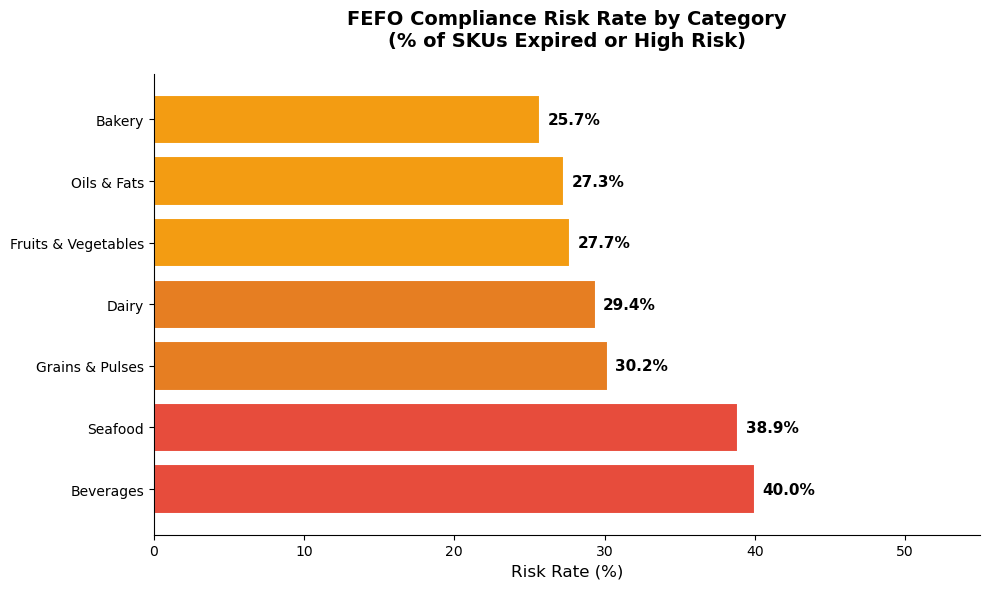

Chart saved!


In [10]:
# Q2 — Visualization: FEFO Risk Rate by Category

fig, ax = plt.subplots(figsize=(10, 6))

colors = ['#e74c3c' if r >= 35 else '#e67e22' if r >= 28 else '#f39c12' 
          for r in fefo_analysis['risk_rate']]

bars = ax.barh(fefo_analysis['Category'], 
               fefo_analysis['risk_rate'],
               color=colors,
               edgecolor='white',
               linewidth=1.5)

# Add value labels
for bar, val in zip(bars, fefo_analysis['risk_rate']):
    ax.text(bar.get_width() + 0.5, 
            bar.get_y() + bar.get_height()/2,
            f'{val}%',
            va='center', fontsize=11, fontweight='bold')

ax.set_title('FEFO Compliance Risk Rate by Category\n(% of SKUs Expired or High Risk)', 
             fontsize=14, fontweight='bold', pad=20)
ax.set_xlabel('Risk Rate (%)', fontsize=12)
ax.set_xlim(0, 55)
ax.spines['top'].set_visible(False)
ax.spines['right'].set_visible(False)

plt.tight_layout()
plt.savefig('outputs/charts/Q2_fefo_risk_by_category.png', dpi=150, bbox_inches='tight')
plt.show()

print("Chart saved!")

In [11]:
# ============================================================
# Q3 — DEMAND VARIABILITY & PERISHABLE PLANNING
# Goal: Which categories have highest demand volatility?
# Business context: High volatility = harder to plan replenishment
# for perishable ingredients
# ============================================================

# Add week column for time series aggregation
sales['week'] = sales['transaction_date'].dt.to_period('W')

# Aggregate sales by week and category
weekly_demand = sales.groupby(['week', 'aisle'])['quantity'].sum().reset_index()
weekly_demand.columns = ['week', 'category', 'total_quantity']

# Calculate variability metrics per category
demand_variability = weekly_demand.groupby('category').agg(
    mean_demand=('total_quantity', 'mean'),
    std_demand=('total_quantity', 'std'),
    min_demand=('total_quantity', 'min'),
    max_demand=('total_quantity', 'max')
).round(1).reset_index()

# Coefficient of Variation (CV) = std / mean * 100
# Higher CV = more volatile demand
demand_variability['cv_percent'] = (demand_variability['std_demand'] / demand_variability['mean_demand'] * 100).round(1)
demand_variability = demand_variability.sort_values('cv_percent', ascending=False)

print("=== DEMAND VARIABILITY BY CATEGORY ===")
print(demand_variability.to_string(index=False))

=== DEMAND VARIABILITY BY CATEGORY ===
         category  mean_demand  std_demand  min_demand  max_demand  cv_percent
     Canned Goods          6.9         4.8           1          24        69.6
    Personal Care          6.9         4.4           1          28        63.8
            Dairy          6.3         3.9           1          16        61.9
     Frozen Foods          6.0         3.7           1          14        61.7
   Meat & Seafood          5.7         3.5           1          21        61.4
           Bakery          5.9         3.6           1          16        61.0
   Snacks & Candy          6.3         3.7           1          17        58.7
  Household Items          5.9         3.4           1          14        57.6
        Beverages          6.7         3.8           1          17        56.7
Health & Wellness          6.3         3.5           1          20        55.6
          Produce          5.9         3.2           1          16        54.2


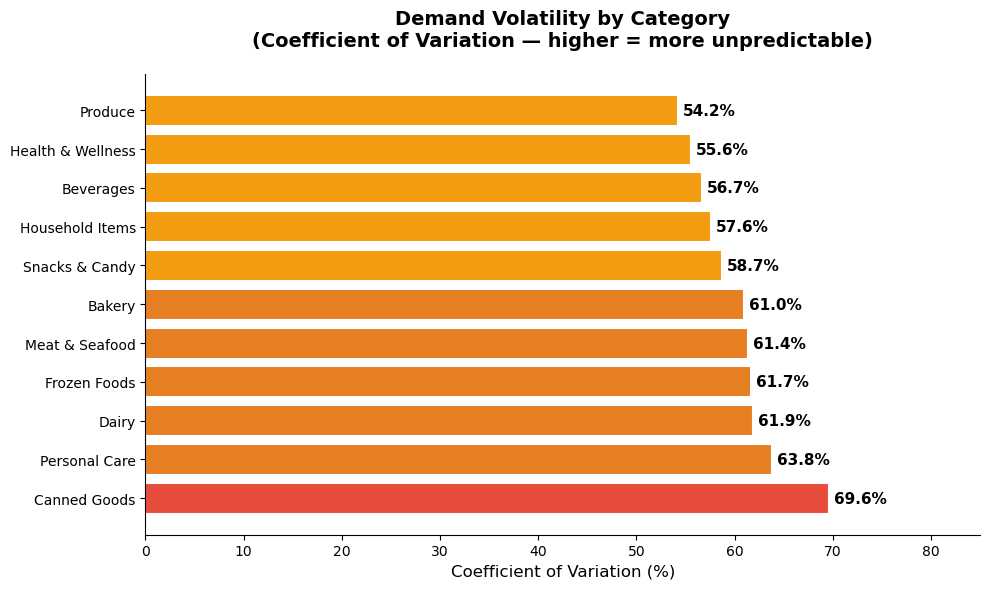

Chart saved!


In [12]:
# Q3 — Visualization: Demand Variability by Category

fig, ax = plt.subplots(figsize=(10, 6))

colors = ['#e74c3c' if cv >= 65 else '#e67e22' if cv >= 60 else '#f39c12' 
          for cv in demand_variability['cv_percent']]

bars = ax.barh(demand_variability['category'],
               demand_variability['cv_percent'],
               color=colors,
               edgecolor='white',
               linewidth=1.5)

for bar, val in zip(bars, demand_variability['cv_percent']):
    ax.text(bar.get_width() + 0.5,
            bar.get_y() + bar.get_height()/2,
            f'{val}%',
            va='center', fontsize=11, fontweight='bold')

ax.set_title('Demand Volatility by Category\n(Coefficient of Variation — higher = more unpredictable)',
             fontsize=14, fontweight='bold', pad=20)
ax.set_xlabel('Coefficient of Variation (%)', fontsize=12)
ax.set_xlim(0, 85)
ax.spines['top'].set_visible(False)
ax.spines['right'].set_visible(False)

plt.tight_layout()
plt.savefig('outputs/charts/Q3_demand_variability.png', dpi=150, bbox_inches='tight')
plt.show()

print("Chart saved!")